# Lesson 4: Flexible Noise Curves — the `FlexibleNoiseRiskModel`

## Motivation: noise in natural space vs log space

The PMCM (lesson 3) assumes a single fixed noise level per presentation position:
$\nu_1$ for the first option and $\nu_2$ for the second.  These scalars are defined in
**natural (linear) payoff space**.

The NLC model predicts **scale invariance**: noise is constant on a *logarithmic* scale.
When translated back to natural space, constant log-scale noise implies that natural-space
noise grows **linearly** with magnitude — this is just Weber's law:

$$\nu_\text{natural}(n) = \nu_\text{log} \times n$$

So the scale-invariant prediction for the flexible model is a *linear* curve $\nu(n)
\propto n$, not a flat one.  A flat curve in natural space would mean constant absolute
discriminability — which would actually imply *improving* relative precision at higher
magnitudes (a violation of Weber's law in the opposite direction).

The **Flexible Noise Model** replaces fixed scalars with **polynomial curves**
$\nu_k(n)$, allowing the data to reveal the actual noise-vs-magnitude relationship:

$$\nu_k(n) = \text{softplus}\!\left(\sum_{j=0}^{p} \beta_{k,j}\, \phi_j(n)\right)$$

where $\phi_j$ are polynomial basis functions and $p$ is the polynomial order (default 5).

- **Linear posterior** $\Rightarrow$ scale invariance (Weber's law) holds
- **Sub-linear** $\Rightarrow$ better-than-Weber precision at large magnitudes
- **Super-linear or curved** $\Rightarrow$ violations (e.g., compressed representation at extremes)

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az
from bauer.utils.data import load_dehollander2024
from bauer.models import RiskModel, FlexibleNoiseRiskModel

# Use dot-cloud data (both sessions) as in lesson 3
df_dot = load_dehollander2024(task='dotcloud', sessions=['3t2', '7t2'])
print(f"Subjects: {df_dot.index.get_level_values('subject').nunique()},  Trials: {len(df_dot)}")

# Prep helper (same as lesson 3)
def prep_df(df):
    df = df.reset_index()
    risky_first = df['p1'] == 0.55
    df['log_ratio']     = np.log(
        np.where(risky_first, df['n1'], df['n2']) /
        np.where(risky_first, df['n2'], df['n1']))
    df['chose_risky']   = np.where(risky_first, ~df['choice'], df['choice'])
    df['n_safe']        = np.where(risky_first, df['n2'], df['n1'])
    df['risky_first']   = risky_first
    df['order']         = np.where(risky_first, 'Risky first', 'Safe first')
    df['log_ratio_bin'] = (pd.cut(df['log_ratio'], bins=10)
                             .apply(lambda x: x.mid).astype(float))
    df['n_safe_bin']    = pd.qcut(df['n_safe'], q=3,
                                   labels=['Low stakes', 'Mid stakes', 'High stakes'])
    return df

df_dot_p = prep_df(df_dot)

Subjects: 30,  Trials: 11445


## Illustrating flexible noise curves

Before fitting, we show what different noise-curve shapes look like and how they
would shift the psychometric function at different magnitude levels.

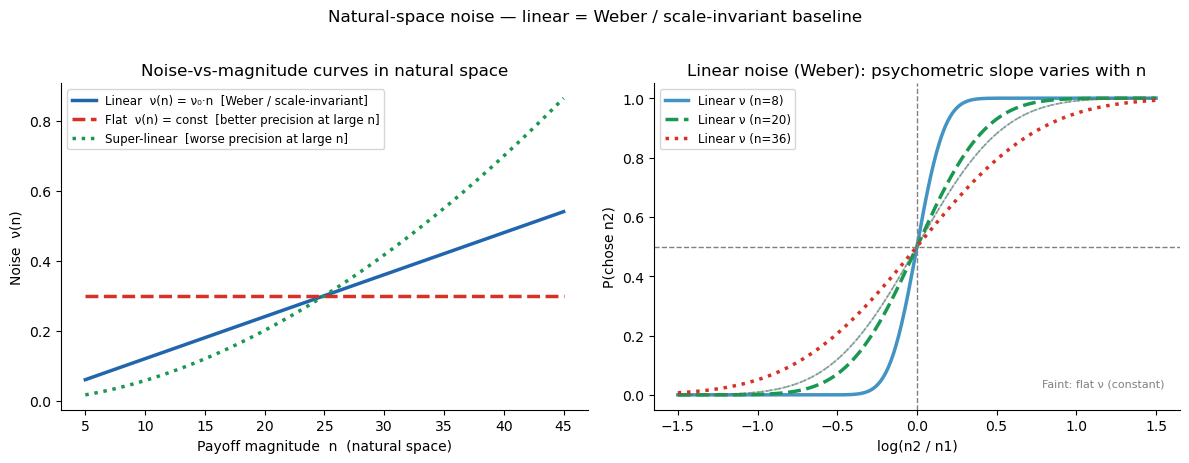

In [2]:
from scipy.stats import norm as scipy_norm

n_vals     = np.linspace(5, 45, 200)
nu_log     = 0.30          # log-scale Weber fraction
log_ratios = np.linspace(-1.5, 1.5, 300)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: noise curves in natural space — linear = Weber's law null
ax = axes[0]
noise_curves = [
    ('Linear  ν(n) = ν₀·n  [Weber / scale-invariant]',
     nu_log * n_vals / n_vals.mean(),        '#2166ac', '-'),
    ('Flat  ν(n) = const  [better precision at large n]',
     np.full_like(n_vals, nu_log),           '#d73027', '--'),
    ('Super-linear  [worse precision at large n]',
     nu_log * (n_vals / n_vals.mean())**1.8, '#1a9850', ':'),
]
for label, nu_n, c, ls in noise_curves:
    ax.plot(n_vals, nu_n, lw=2.5, color=c, ls=ls, label=label)
ax.set_xlabel('Payoff magnitude  n  (natural space)')
ax.set_ylabel('Noise  ν(n)')
ax.set_title('Noise-vs-magnitude curves in natural space')
ax.legend(fontsize=8.5); sns.despine(ax=ax)

# Right: linear = constant log-ratio discrimination (Weber law)
ax = axes[1]
for n_ref, c, ls in [(8, '#4393c3', '-'), (20, '#1a9850', '--'), (36, '#d73027', ':')]:
    nu_lin  = nu_log * n_ref / n_vals.mean()   # linear Weber noise
    nu_flat = nu_log                            # flat (constant) noise
    p_lin  = scipy_norm.cdf(log_ratios / (np.sqrt(2) * nu_lin))
    p_flat = scipy_norm.cdf(log_ratios / (np.sqrt(2) * nu_flat))
    ax.plot(log_ratios, p_lin,  color=c, lw=2.5, ls=ls, label=f'Linear ν (n={n_ref})')
    ax.plot(log_ratios, p_flat, color=c, lw=1.2, ls=ls, alpha=.4)
ax.axhline(.5, ls='--', c='gray', lw=1)
ax.axvline(0,  ls='--', c='gray', lw=1)
ax.text(0.97, 0.07, 'Faint: flat ν (constant)', transform=ax.transAxes,
        ha='right', fontsize=8, color='gray')
ax.set_xlabel('log(n2 / n1)')
ax.set_ylabel('P(chose n2)')
ax.set_title('Linear noise (Weber): psychometric slope varies with n')
ax.legend(fontsize=8.5); sns.despine(ax=ax)

plt.suptitle('Natural-space noise — linear = Weber / scale-invariant baseline',
             fontsize=12, y=1.02)
plt.tight_layout()

## Fit models — PMCM vs Flexible Noise

We fit both the PMCM (fixed noise) and the Flexible Noise model on the dot-cloud data
so we can directly compare them.

In [3]:
# ── PMCM (fixed noise) ───────────────────────────────────────────────────────
model_pmcm = RiskModel(paradigm=df_dot, prior_estimate='full',
                        fit_seperate_evidence_sd=True)
model_pmcm.build_estimation_model(data=df_dot, hierarchical=True, save_p_choice=True)
idata_pmcm = model_pmcm.sample(draws=100, tune=100, chains=2, progressbar=True)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [n1_evidence_sd_mu_untransformed, n1_evidence_sd_sd, n1_evidence_sd_offset, n2_evidence_sd_mu_untransformed, n2_evidence_sd_sd, n2_evidence_sd_offset, risky_prior_mu_mu, risky_prior_mu_sd, risky_prior_mu_offset, risky_prior_sd_mu_untransformed, risky_prior_sd_sd, risky_prior_sd_offset, safe_prior_mu_mu, safe_prior_mu_sd, safe_prior_mu_offset, safe_prior_sd_mu_untransformed, safe_prior_sd_sd, safe_prior_sd_offset]


Output()

Sampling 2 chains for 100 tune and 100 draw iterations (200 + 200 draws total) took 70 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [4]:
# ── Flexible Noise model (polynomial noise curves) ───────────────────────────
model_flex = FlexibleNoiseRiskModel(paradigm=df_dot, prior_estimate='full',
                                     fit_seperate_evidence_sd=True, polynomial_order=5)
model_flex.build_estimation_model(paradigm=df_dot, hierarchical=True, save_p_choice=True)
idata_flex = model_flex.sample(draws=100, tune=100, chains=2, progressbar=True)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [n1_evidence_sd_spline1_mu, n1_evidence_sd_spline1_sd, n1_evidence_sd_spline1_offset, n1_evidence_sd_spline2_mu, n1_evidence_sd_spline2_sd, n1_evidence_sd_spline2_offset, n1_evidence_sd_spline3_mu, n1_evidence_sd_spline3_sd, n1_evidence_sd_spline3_offset, n1_evidence_sd_spline4_mu, n1_evidence_sd_spline4_sd, n1_evidence_sd_spline4_offset, n1_evidence_sd_spline5_mu, n1_evidence_sd_spline5_sd, n1_evidence_sd_spline5_offset, n2_evidence_sd_spline1_mu, n2_evidence_sd_spline1_sd, n2_evidence_sd_spline1_offset, n2_evidence_sd_spline2_mu, n2_evidence_sd_spline2_sd, n2_evidence_sd_spline2_offset, n2_evidence_sd_spline3_mu, n2_evidence_sd_spline3_sd, n2_evidence_sd_spline3_offset, n2_evidence_sd_spline4_mu, n2_evidence_sd_spline4_sd, n2_evidence_sd_spline4_offset, n2_evidence_sd_spline5_mu, n2_evidence_sd_spline5_sd, n2_evidence_sd_spline5_offset, risky_prior_mu_mu, risky_prior_mu_sd, risky_prior_mu_offset, risky_prior_sd_mu_untransformed, risky_prior_sd_sd, risky_prior_sd_offset, safe_pr

Output()

Sampling 2 chains for 100 tune and 100 draw iterations (200 + 200 draws total) took 223 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


## Posterior noise curves $\nu_k(n)$

The group-level posterior noise curves show whether noise is flat (like PMCM assumes)
or varies systematically with magnitude.  The shaded band is the 95 % posterior interval
across posterior samples.

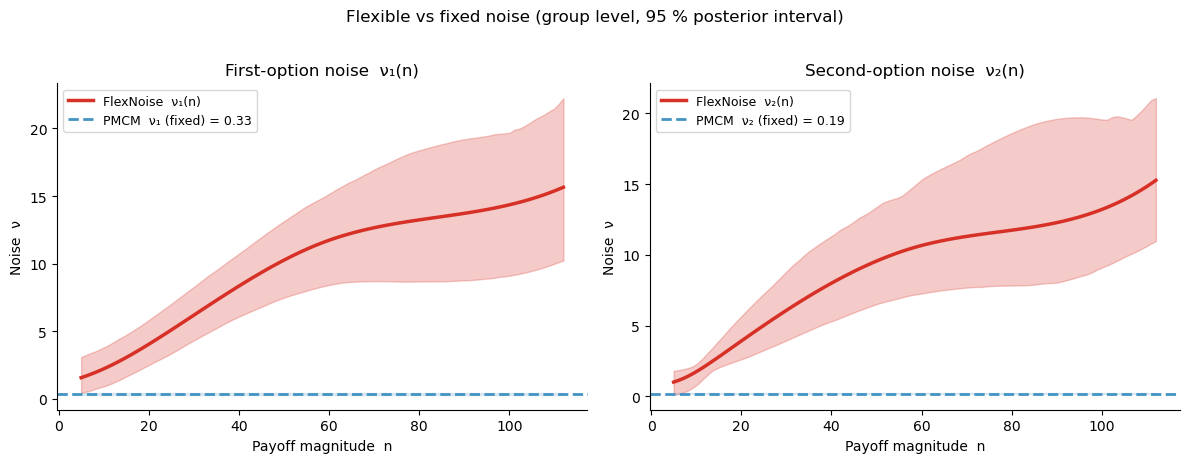

In [5]:
# Get group-level noise curves from the flexible model
# Returns long-format DataFrame with MultiIndex (chain, draw, x)
sd_curves = model_flex.get_sd_curve(idata=idata_flex, variable='both',
                                     group=True, data=df_dot.reset_index())

# PMCM fixed noise posteriors (scalar per sample)
nu1_pmcm = idata_pmcm.posterior['n1_evidence_sd_mu'].values.ravel()
nu2_pmcm = idata_pmcm.posterior['n2_evidence_sd_mu'].values.ravel()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
colors = {'flex': '#d73027', 'pmcm': '#4393c3'}

for ax, (var_col, nu_pmcm, label_flex, label_pmcm) in zip(
        axes,
        [('n1_evidence_sd', nu1_pmcm, 'FlexNoise  ν₁(n)', 'PMCM  ν₁ (fixed)'),
         ('n2_evidence_sd', nu2_pmcm, 'FlexNoise  ν₂(n)', 'PMCM  ν₂ (fixed)')]):
    # Group by x to get posterior mean and 95% CI across (chain, draw) samples
    grp    = sd_curves.groupby(level='x')[var_col]
    x_vals = grp.mean().index.values
    mean   = grp.mean().values
    lo     = grp.quantile(0.025).values
    hi     = grp.quantile(0.975).values
    ax.fill_between(x_vals, lo, hi, alpha=.25, color=colors['flex'])
    ax.plot(x_vals, mean, lw=2.5, color=colors['flex'], label=label_flex)
    # PMCM fixed noise
    ax.axhline(nu_pmcm.mean(), ls='--', lw=2, color=colors['pmcm'],
               label=f'{label_pmcm} = {nu_pmcm.mean():.2f}')
    ax.fill_between(x_vals,
                    np.percentile(nu_pmcm, 2.5),
                    np.percentile(nu_pmcm, 97.5),
                    alpha=.15, color=colors['pmcm'])
    ax.set_xlabel('Payoff magnitude  n')
    ax.set_ylabel('Noise  ν')
    ax.legend(fontsize=9); sns.despine(ax=ax)

axes[0].set_title('First-option noise  ν₁(n)')
axes[1].set_title('Second-option noise  ν₂(n)')
plt.suptitle('Flexible vs fixed noise (group level, 95 % posterior interval)',
             fontsize=12, y=1.02)
plt.tight_layout()

## Posterior predictive comparison

We reuse the PPC helper from lesson 3 and overlay both models' predictions against the
observed presentation-order × stake-size interaction.

Sampling: []


Output()

Sampling: []


Output()

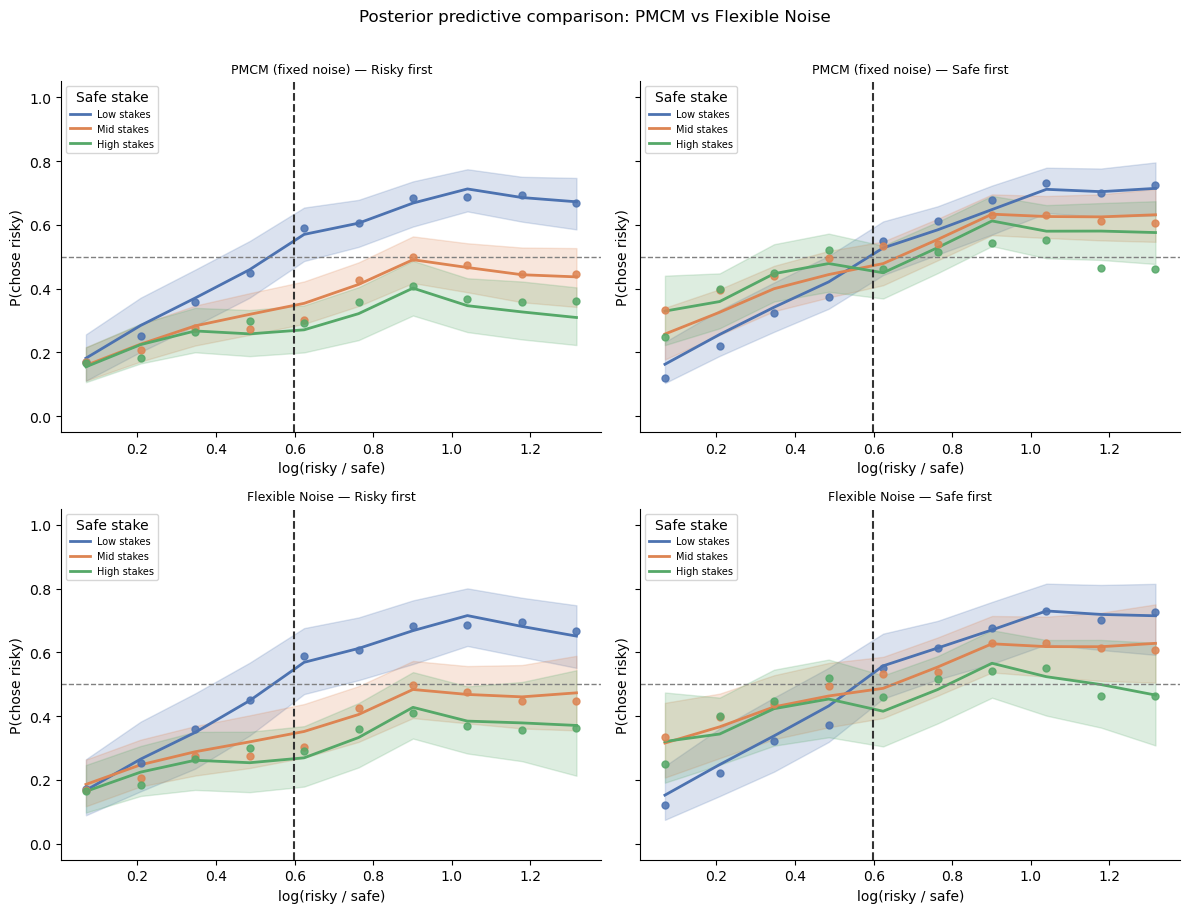

In [6]:
stake_pal = {'Low stakes': '#4C72B0', 'Mid stakes': '#DD8452', 'High stakes': '#55A868'}

def add_model_ppc(df_orig, df_prepped, model, idata, model_name, n_ppc_samples=50):
    ppc_df = model.ppc(df_orig, idata, var_names=['p'])
    ppc_p  = ppc_df.xs('p', level='variable')
    cols   = np.random.choice(ppc_p.columns,
                               size=min(n_ppc_samples, ppc_p.shape[1]),
                               replace=False)
    ppc_p  = ppc_p[cols]
    risky_first = df_prepped['risky_first'].values
    p_risky = np.where(risky_first[:, None], 1 - ppc_p.values, ppc_p.values)
    df_out = df_prepped.copy()
    df_out['p_mean'] = p_risky.mean(1)
    df_out['p_lo']   = np.percentile(p_risky, 2.5,  axis=1)
    df_out['p_hi']   = np.percentile(p_risky, 97.5, axis=1)
    df_out['model']  = model_name
    return df_out


def plot_ppc_row(df_pred, model_name, axes_row):
    hue_order = ['Low stakes', 'Mid stakes', 'High stakes']
    for ax, order_val in zip(axes_row, ['Risky first', 'Safe first']):
        sub  = df_pred[df_pred['order'] == order_val]
        obs  = sub.groupby(['n_safe_bin', 'log_ratio_bin'])['chose_risky'].mean().reset_index()
        pred = (sub.groupby(['n_safe_bin', 'log_ratio_bin'])[['p_mean', 'p_lo', 'p_hi']]
                   .mean().reset_index())
        for sbin in hue_order:
            o = obs[obs['n_safe_bin']  == sbin]
            p = pred[pred['n_safe_bin'] == sbin]
            if len(o) == 0:
                continue
            c = stake_pal[sbin]
            ax.fill_between(p['log_ratio_bin'], p['p_lo'], p['p_hi'], color=c, alpha=.2)
            ax.plot(p['log_ratio_bin'], p['p_mean'], color=c, lw=2, label=sbin)
            ax.scatter(o['log_ratio_bin'], o['chose_risky'],
                       color=c, s=25, zorder=5, alpha=.85)
        ax.axhline(.5, ls='--', c='gray', lw=1)
        ax.axvline(np.log(1/.55), ls='--', c='#333333', lw=1.5)
        ax.set_ylim(-.05, 1.05)
        ax.set_title(f'{model_name} — {order_val}', fontsize=9)
        ax.set_xlabel('log(risky / safe)'); ax.set_ylabel('P(chose risky)')
        ax.legend(title='Safe stake', fontsize=7, loc='upper left')
        sns.despine(ax=ax)


fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharey=True)
for (mdl, idat, name), row in zip(
        [(model_pmcm, idata_pmcm, 'PMCM (fixed noise)'),
         (model_flex, idata_flex, 'Flexible Noise')],
        axes):
    df_pred = add_model_ppc(df_dot, df_dot_p, mdl, idat, name)
    plot_ppc_row(df_pred, name, row)

plt.suptitle('Posterior predictive comparison: PMCM vs Flexible Noise',
             fontsize=12, y=1.01)
plt.tight_layout()

## Take-aways

- If the posterior noise curves are **flat**, the flexible model reduces to the PMCM
  and adds no explanatory value.
- If the curves are **rising or curved**, this indicates that noise is not constant
  across magnitudes — violating the pure scale-invariance prediction of the NLC model.
- The flexible model's PPC will tend to capture the stake-dependent spread more
  accurately when noise truly varies, because it can assign different noise to high-
  and low-magnitude safe/risky options within the same trial.
- In practice, compare model fit with `az.compare({'PMCM': idata_pmcm, 'Flex': idata_flex})`
  after computing log-likelihoods (requires `idata_kwargs={'log_likelihood': True}` in
  `model.sample()`).